In [5]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd


In [6]:
from tqdm import tqdm
import h5py

from multicam_tng.utils import convert_tng_mass

# Read data

In [ ]:
# dmo
subhalo_ids_dark = []
subhalo_mass = []

count = 0
for ii in tqdm(range(0, 64)):
    filename = f'../../data/tng100-dark/fof_subhalo_tab_099.{ii}.hdf5'
    with h5py.File(filename, 'r') as f:

        
        if 'SubhaloMass' in f['Subhalo'].keys():
            for s in f['Subhalo']['SubhaloMass']:
                subhalo_ids_dark.append(count)
                subhalo_mass.append(s)
                count+=1


subhalo_ids_dark = np.array(subhalo_ids_dark)
subhalo_mass = convert_tng_mass(np.array(subhalo_mass)) # log10(Msun / h)
# group_mass = convert_tng_mass2(np.array(group_mass))
# hat_group_mass = convert_tng_mass2(np.array(hat_group_mass))

  0%|          | 0/64 [00:00<?, ?it/s]

100%|██████████| 64/64 [00:05<00:00, 10.70it/s]


In [8]:
subhalo_ids_dark.shape, subhalo_mass.shape

((5012155,), (5012155,))

In [9]:
# hydro
subhalo_ids = []
stellar_mass = []
subhalo_mass_hydro = []

count = 0
for ii in tqdm(range(0, 448)):
    filename = f'../../data/tng100/fof_subhalo_tab_099.{ii}.hdf5'
    with h5py.File(filename, 'r') as f:

            

        if 'SubhaloMass' in f['Subhalo'].keys():
            for s in f['Subhalo']['SubhaloMass']:
                subhalo_ids.append(count)
                subhalo_mass_hydro.append(s)
                count+=1

            for s in f['Subhalo']['SubhaloMassInRadType'][:,4]: # 4 = star particles
                stellar_mass.append(s) 


subhalo_ids = np.array(subhalo_ids)
subhalo_mass_hydro = convert_tng_mass(np.array(subhalo_mass_hydro)) # log10(Msun / h)
stellar_mass = convert_tng_mass(np.array(stellar_mass)) # log10(Msun / h)
# group_mass = convert_tng_mass2(np.array(group_mass))
# hat_group_mass = convert_tng_mass2(np.array(hat_group_mass))

100%|██████████| 448/448 [00:06<00:00, 69.26it/s] 
/Users/imendoza/code/multicam-tng-mah/multicam_tng/utils.py:35: RuntimeWarning: divide by zero encountered in log10
  return np.where(gmass > 0, np.log10(gmass * 1e10 / TNG_H), 0)


In [10]:
stellar_mass.shape, subhalo_ids.shape

((4371211,), (4371211,))

# Histogram 

In [12]:
bp_mass = 1.4e6

212929


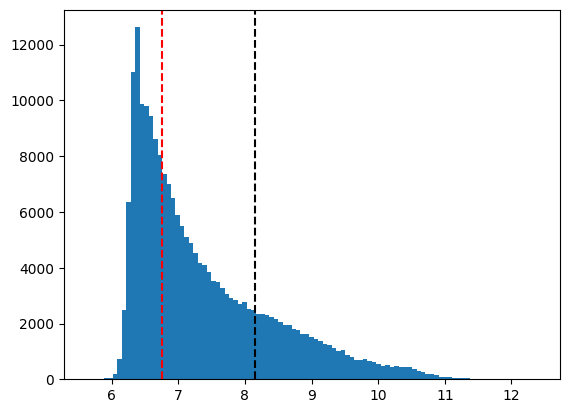

In [13]:
mask = stellar_mass > 0
plt.hist(stellar_mass[mask], bins=101);
plt.axvline(6.75, c='r', ls='--', label='6.75 example cut')
plt.axvline(np.log10(bp_mass * 100), c='k', ls='--', label='>100 particles')
print(sum(mask))

4371211


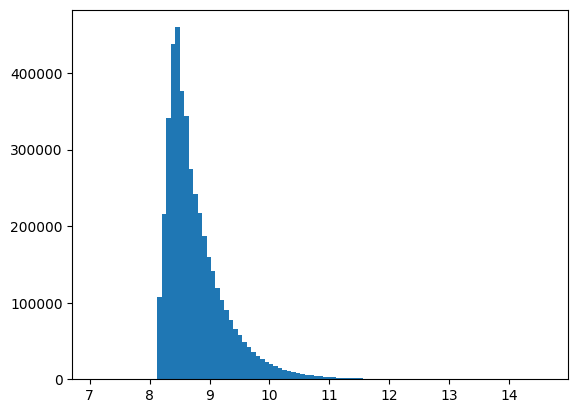

In [27]:
mask = subhalo_mass_hydro > 0
plt.hist(subhalo_mass_hydro[mask], bins=101);
# plt.axvline(6.75, c='r', ls='--', label='6.75 example cut')
print(sum(mask))

In [44]:
smbin = (8.0, 8.1)
mask1 = (stellar_mass > smbin[0]) & (stellar_mass < smbin[1])
sum(mask1)

np.int64(3865)

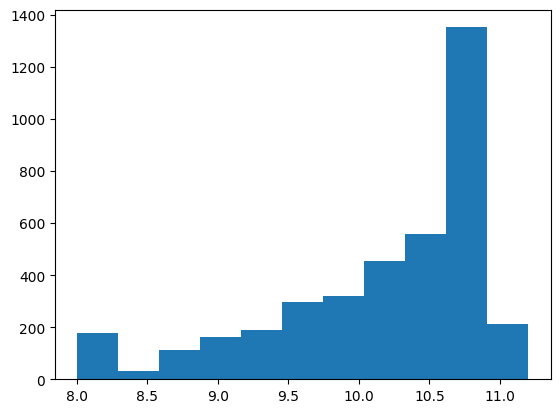

In [45]:
# what dmo bin contains most of these galaxies?
# np.quantile(subhalo_mass_hydro[mask], 0.01), np.quantile(subhalo_mass_hydro[mask], 0.99)
plt.hist(subhalo_mass_hydro[mask1], bins=11);

In [29]:
# _mask = (stellar_mass > 0) & (subhalo_mass_hydro > 0)
# y = 10**stellar_mass[_mask] / 10**subhalo_mass_hydro[_mask]
# plt.plot(subhalo_mass_hydro[_mask], np.log10(y) , 'o', markersize=2, alpha=0.01)

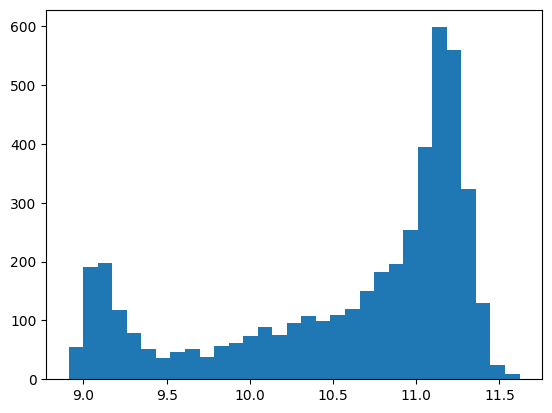